In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, ADASYN

In [23]:
DATA_DIR = '../data/raw/raw_data.csv'
df = pd.read_csv(DATA_DIR)

# Imbalance Analysis and Mitigation

In this section, we analyze the class imbalance present in the dataset and we provide different approaches to mitigate it. Among these different techniques, we find SMOTE, ADASYN, Oversampling and Subsampling. After handling imbalance we will save each of the resulting balanced datasets to later train and test our models.

## Visualization of the Imbalance

In the graphic bellow we observe the class imbalance previously discussed in the EDA. We clearly see that there are 2 majority classes that dominate over the other 5.

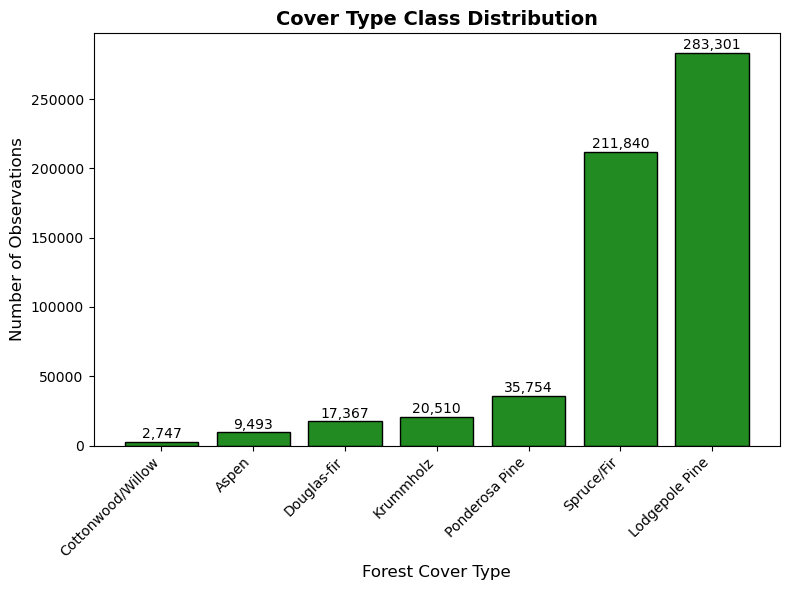

In [24]:
# Covertype Mapping
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

df['class_name'] = df['Cover_Type'].map(covertype_class)

class_counts = df['class_name'].value_counts().sort_values(ascending=True)
# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values, color='forestgreen', edgecolor='black')

for i, (name, count) in enumerate(zip(class_counts.index, class_counts.values)):
        plt.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.title('Cover Type Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Forest Cover Type', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Mitigation Approaches
* *Oversampling*: This approach consists on generating syntehtic data from the already existing one.
    * *SMOTE*
    * *ADASYN*
* *Undersampling*: This approach consists on removing data from the majority classes. The samples removed depend on the approach followed.
    * Controlled Under-sampling
        * *Random Undersampling*
        * *NearMiss*
    * Cleaning Under-sampling
        * *Tomek's Links*
        * *Edited Nearest Neighbors*

### OVERSAMPLING

#### SMOTE

In [4]:
from collections import Counter
X = df.drop(columns=['Cover_Type', 'class_name'], axis=1)
y = df['Cover_Type']

print(f"Shape of the dataset: {Counter(y)}")

Shape of the dataset: Counter({2: 283301, 1: 211840, 3: 35754, 7: 20510, 6: 17367, 5: 9493, 4: 2747})


In [5]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X,y)
print(f"Shape of the dataset after SMOTE: {Counter(y_resampled)}")

Shape of the dataset after SMOTE: Counter({5: 283301, 2: 283301, 1: 283301, 7: 283301, 3: 283301, 6: 283301, 4: 283301})


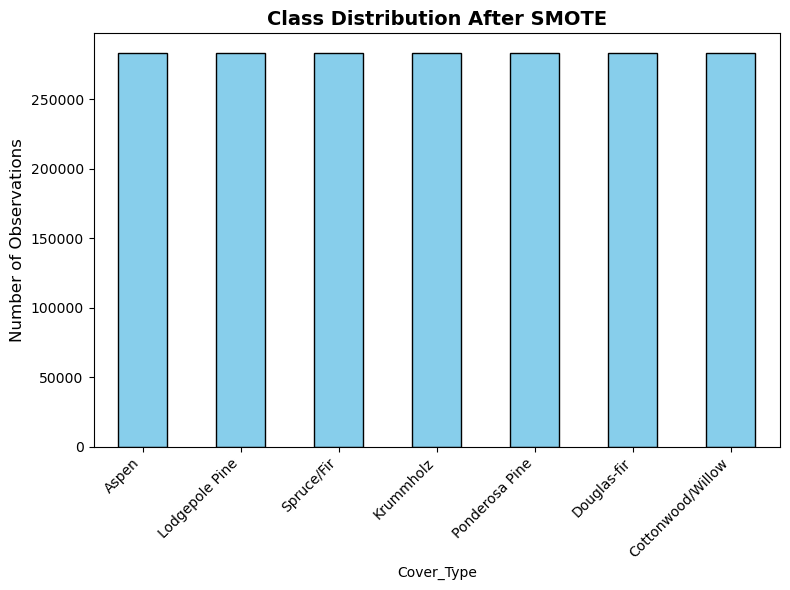

In [27]:
resampled_counts = pd.Series(y_resampled).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
resampled_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_resampled = pd.DataFrame(x_resampled, columns=X.columns)
df_resampled['Cover_Type'] = y_resampled

df_resampled.to_parquet('../data/processed/smote_balanced.parquet', index=False)

#### ADASYN

In [7]:
adasyn = ADASYN(random_state=42)
x_adasyn, y_adasyn = adasyn.fit_resample(X,y)
print(f"Shape of the dataset after ADASYN: {Counter(y_adasyn)}")

Shape of the dataset after ADASYN: Counter({5: 283537, 2: 283301, 4: 283284, 7: 282662, 6: 282644, 3: 282268, 1: 277125})


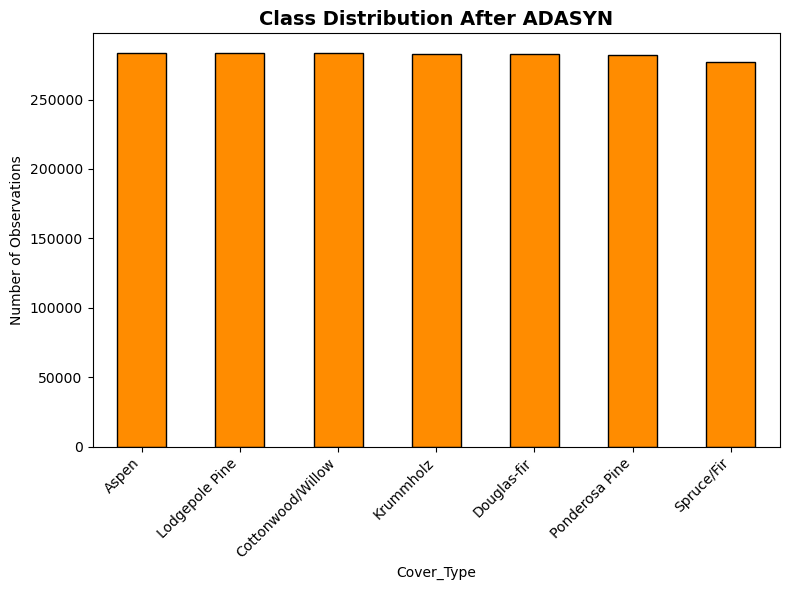

In [8]:
adasyn_counts = pd.Series(y_adasyn).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
adasyn_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Class Distribution After ADASYN', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df_resampled = pd.DataFrame(x_adasyn, columns=X.columns)
df_resampled['Cover_Type'] = y_adasyn

df_resampled.to_parquet('../data/processed/adasyn_balanced.parquet', index=False)

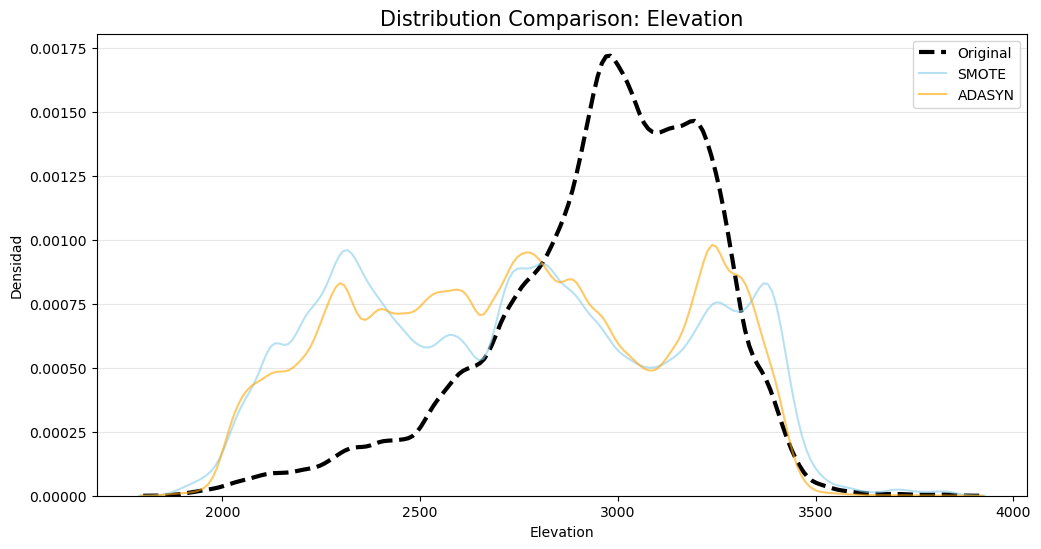

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

df_smote = pd.read_parquet('../data/processed/smote_balanced.parquet')
df_adasyn = pd.read_parquet('../data/processed/adasyn_balanced.parquet')

def plot_distribution_comparison(df_orig, df_smote, df_adasyn, feature='Elevation'):
    plt.figure(figsize=(12, 6))
    
    sns.kdeplot(df_orig[feature], label='Original', color='black', linewidth=3, linestyle='--')
    sns.kdeplot(df_smote[feature], label='SMOTE', color='skyblue', alpha=0.6)
    sns.kdeplot(df_adasyn[feature], label='ADASYN', color='orange', alpha=0.6)
    
    plt.title(f'Distribution Comparison: {feature}', fontsize=15)
    plt.xlabel(feature)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_distribution_comparison(df, df_smote, df_adasyn, feature='Elevation')

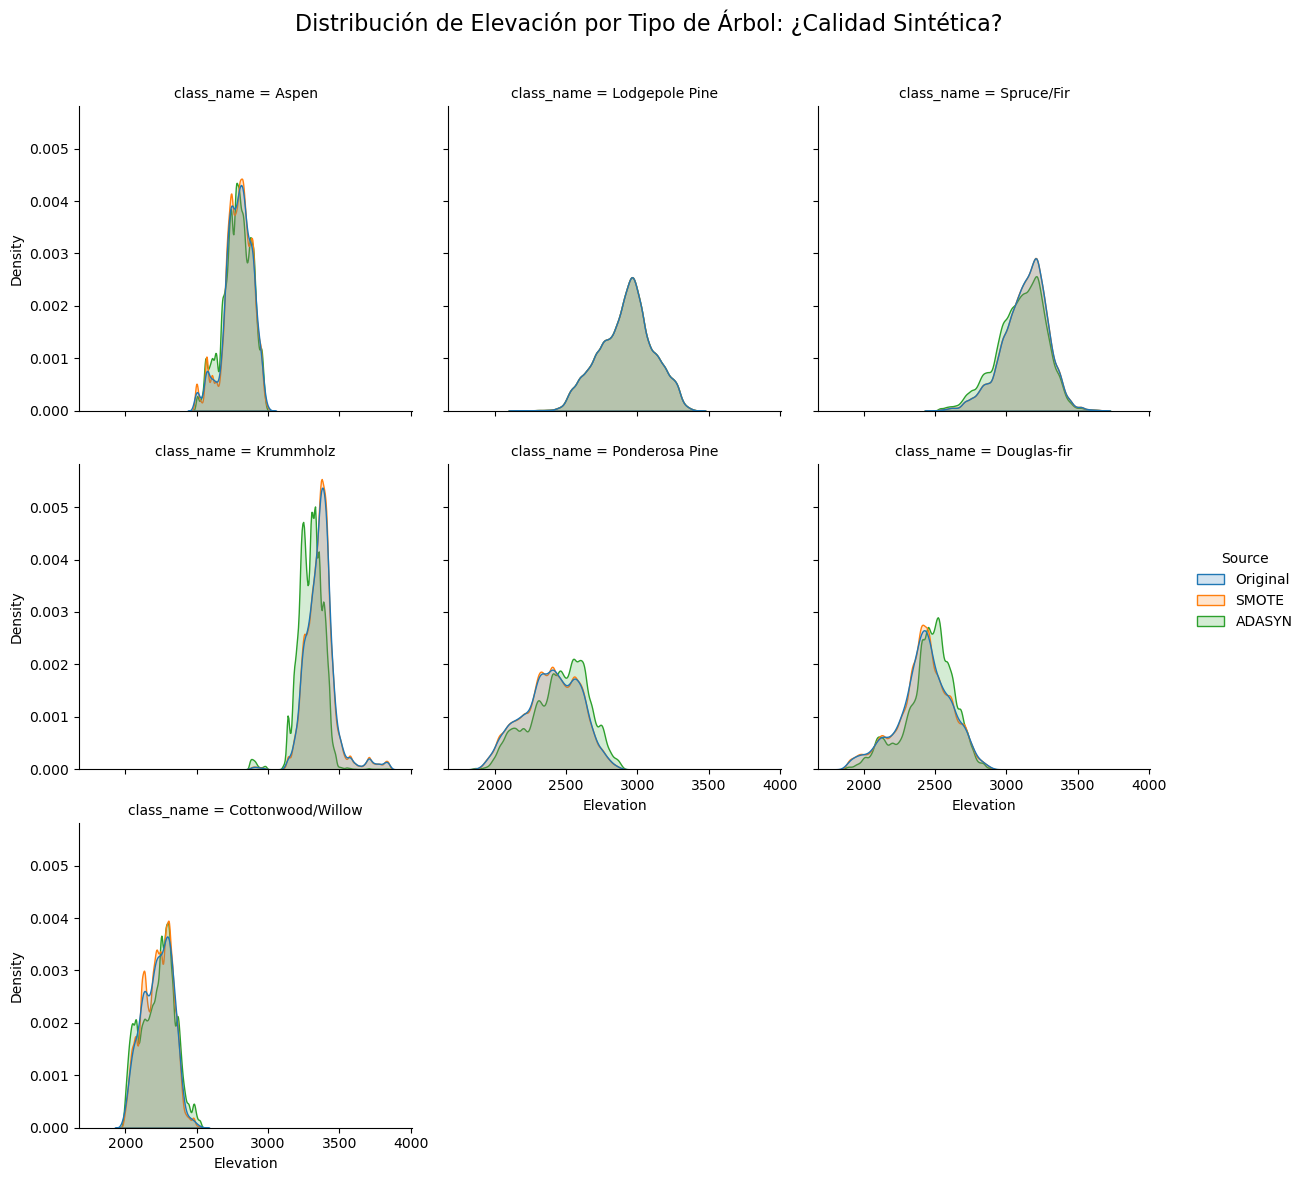

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Asegúrate de tener los DataFrames listos con sus etiquetas
df_orig_plot = df.copy()
df_orig_plot['Source'] = 'Original'

# Convertimos los arrays de salida de SMOTE/ADASYN a DataFrames
# Nota: Asegúrate de añadir las columnas que tenías originalmente
df_smote_plot = pd.DataFrame(x_resampled, columns=X.columns)
df_smote_plot['Cover_Type'] = y_resampled
df_smote_plot['class_name'] = df_smote_plot['Cover_Type'].map(covertype_class)
df_smote_plot['Source'] = 'SMOTE'

df_adasyn_plot = pd.DataFrame(x_adasyn, columns=X.columns)
df_adasyn_plot['Cover_Type'] = y_adasyn
df_adasyn_plot['class_name'] = df_adasyn_plot['Cover_Type'].map(covertype_class)
df_adasyn_plot['Source'] = 'ADASYN'

# 2. Combinamos todo
combined_df = pd.concat([df_orig_plot, df_smote_plot, df_adasyn_plot], axis=0)

# 3. Plot de comparación (FacetGrid)
g = sns.displot(
    data=combined_df, 
    x='Elevation', 
    hue='Source', 
    col='class_name', 
    kind='kde', 
    col_wrap=3,      # 3 gráficos por fila
    height=4, 
    fill=True, 
    alpha=0.2,
    common_norm=False
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Value Distribution for each Forest Type', fontsize=16)
plt.show()

### UNDERSAMPLING

##### 1. Controlled Under-sampling

#### RANDOM UNDERSAMPLING

In [28]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=0)
x_under, y_under = undersampler.fit_resample(X,y)

print(f"Shape of the dataset after RandomUnderSampler: {Counter(y_under)}")

Shape of the dataset after RandomUnderSampler: Counter({1: 2747, 2: 2747, 3: 2747, 4: 2747, 5: 2747, 6: 2747, 7: 2747})


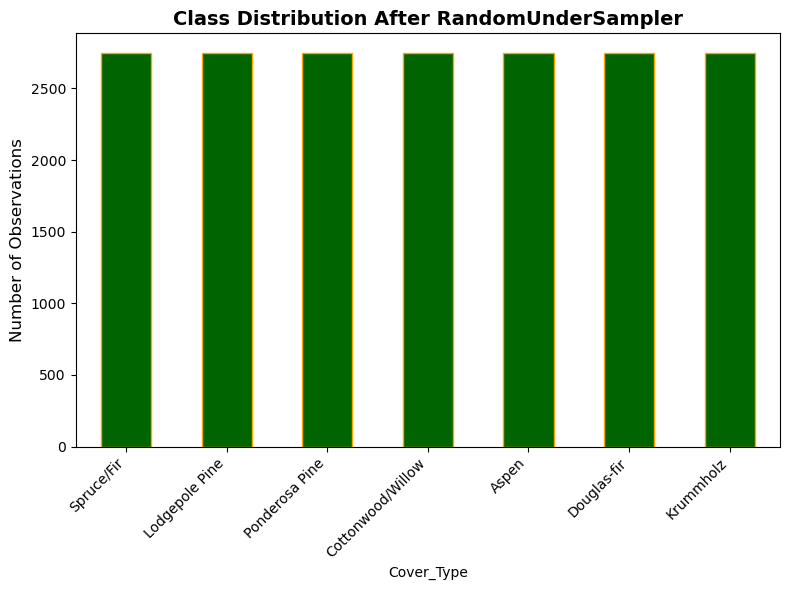

In [29]:
resampled_counts = pd.Series(y_under).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
resampled_counts.plot(kind='bar', color='darkgreen', edgecolor='orange')
plt.title('Class Distribution After RandomUnderSampler', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### NEARMISS

In [30]:
from imblearn.under_sampling import NearMiss

nm = NearMiss()
X_under_nm, y_under_nm = nm.fit_resample(X, y)

print(f"Shape of the dataset after NearMiss: {Counter(y_under_nm)}")

Shape of the dataset after NearMiss: Counter({1: 2747, 2: 2747, 3: 2747, 4: 2747, 5: 2747, 6: 2747, 7: 2747})


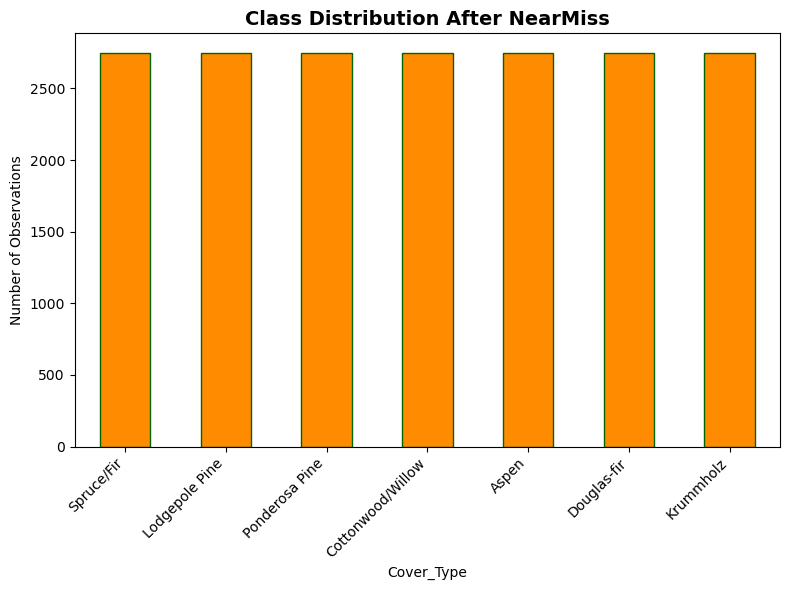

In [32]:
nm_counts = pd.Series(y_under_nm).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
nm_counts.plot(kind='bar', color='darkorange', edgecolor='darkgreen')
plt.title('Class Distribution After NearMiss', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2. Cleaning Under-sampling

#### TOMEK'S LINKS

#### EDITED NEAREST NEIGHBORS